# Mini Project: 
Dataset: Superstore\
By: Daffa Aryo Utomo Sudranto\
Bootcamp Program: Dibimbing.id Data Analyst 3 Offline

**Row ID:** ID unik untuk setiap baris data.\
**Order ID:** ID pesanan unik untuk setiap pelanggan.\
**Order_Date:** Tanggal pemesanan produk.\
**Ship_Date:** Tanggal pengiriman produk.\
**Ship_Mode:** Metode pengiriman yang dipilih oleh pelanggan.\
**Customer ID:** ID unik untuk mengidentifikasi setiap pelanggan.\
**Customer Name:** Nama pelanggan.\
**Segment:** Segmen tempat pelanggan berada.\
**Country:** Negara tempat tinggal pelanggan.\
**City:** Kota tempat tinggal pelanggan.\
**State:** Provinsi/negara bagian tempat tinggal pelanggan.\
**Postal Code:** Kode pos setiap pelanggan.\
**Region:** Wilayah tempat pelanggan berada.\
**Product ID:** ID unik dari produk.\
**Category:** Kategori produk yang dipesan.\
**Sub-Category:** Subkategori dari produk yang dipesan.\
**Product Name:** Nama produk\
**Sales:** Nilai penjualan produk.\
**Quantity:** Jumlah produk yang dibeli.\
**Discount:** Diskon yang diberikan.\
**Profit:** Keuntungan atau kerugian yang diperoleh.

In [113]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import spearmanr

In [114]:
df = pd.read_csv('C:/Dibimbing/POWERBI/ASSIGNMENT/SampleSuperstore.csv', encoding='latin-1')

In [115]:
# setting untuk menampilkan semua kolom
pd.set_option('display.max_columns', None)

# **1. Data Overview**

In [116]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [117]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [118]:
# Jumlah row dan kolom
df.shape

(9994, 21)

- Jumlah Baris: 9994
- Jumlah Kolom: 21

In [119]:
# nama kolom
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [120]:
# tipe data tiap kolom
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

- Terdapat penamaan kolom dengan spasi
- Data tanggal masih dalam bentuk object (seharusnya date)

In [121]:
# statistik kolom numerik
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [122]:
# statistik kolom kategorik
df.describe(include=["object"])

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [123]:
obj_col = df.select_dtypes(include=["object"]).columns # variable untuk mengambil nama kolom object
obj_value = []

# membuat dictionary untuk tabel unique value
for col in obj_col:
    obj_value.append({
        "column_name" : col, #nama kolom
        "unique_value" : df[col].dropna().unique().tolist(), # list unique value 
        "n_unique" : df[col].nunique(dropna=True) # jumlah unique value
    })

# membuat data frame dari dictionary unique value
df_obj_value = pd.DataFrame(obj_value)

In [124]:
df_obj_value

,column_name,unique_value,n_unique
0,Order ID,"[CA-2016-152156, CA-2016-138688, US-2015-10896...",5009
1,Order Date,"[11/8/2016, 6/12/2016, 10/11/2015, 6/9/2014, 4...",1237
2,Ship Date,"[11/11/2016, 6/16/2016, 10/18/2015, 6/14/2014,...",1334
3,Ship Mode,"[Second Class, Standard Class, First Class, Sa...",4
4,Customer ID,"[CG-12520, DV-13045, SO-20335, BH-11710, AA-10...",793
5,Customer Name,"[Claire Gute, Darrin Van Huff, Sean O'Donnell,...",793
6,Segment,"[Consumer, Corporate, Home Office]",3
7,Country,[United States],1
8,City,"[Henderson, Los Angeles, Fort Lauderdale, Conc...",531
9,State,"[Kentucky, California, Florida, North Carolina...",49


In [125]:
# Menampilkan dataframe untuk missing value/data hilang
df_na = pd.DataFrame({
    "missing_value" : df.isna().sum(), # jumlah missing value per kolom
    "percentage(%)" : round((df.isna().mean()*100),2) # persentase missing value per kolom
})
print(df_na.sort_values(by="missing_value", ascending=False)[df_na["missing_value"]>0])
print("\n")
print("Jumlah missing value: ",df_na["missing_value"].sum()) # jumlah missing value keseluruhan
print("Persentase missing value (%): ",round((df_na["percentage(%)"].sum()),2)) # peresentase missing value keseluruhan

Empty DataFrame
Columns: [missing_value, percentage(%)]
Index: []


Jumlah missing value:  0
Persentase missing value (%):  0.0


In [126]:
df.duplicated().sum()

np.int64(0)

- tidak ada missing value
- tidak ada duplikat

# **2. Data Cleaning & Handling**

In [127]:
# Membuat dataframe untuk cleaning
dfc = df.copy()

In [128]:
# Penamaan kembali untuk kolom dataset
kolombaru = []
for i in dfc.columns:
    kolombaru.append(i.strip().replace(" ", "_")) # menghapus spasi tersembunyi dan merubah spasi antar kata dengan underscore (_)

dfc.columns = kolombaru
print(dfc.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [129]:
dfc.head(1)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136


In [130]:
# ganti tipe data object menjadi tanggal
dfc['Order_Date'] = pd.to_datetime(dfc['Order_Date'], format = '%m/%d/%Y')
dfc['Ship_Date'] = pd.to_datetime(dfc['Ship_Date'], format = '%m/%d/%Y')

In [131]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9994 non-null   int64         
 1   Order_ID       9994 non-null   object        
 2   Order_Date     9994 non-null   datetime64[ns]
 3   Ship_Date      9994 non-null   datetime64[ns]
 4   Ship_Mode      9994 non-null   object        
 5   Customer_ID    9994 non-null   object        
 6   Customer_Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal_Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product_ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [132]:
# Kolom numerik
col_numeric = dfc.select_dtypes(include='number').columns[2:]

In [133]:
col_numeric

Index(['Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

In [134]:
# Membuat tabel pemeriksaan outlier
# Metode pemriksaan outlier: IQR
outlier_summary = {}

for n in col_numeric:
    Q1 = dfc[n].quantile(0.25) # Mendapatkan nilai 25% dari dataset
    Q3 = dfc[n].quantile(0.75) # Mendapatkan nilai 75% dari dataset
    IQR = Q3 - Q1

    lowerbond = Q1 - 1.5*IQR # Medapatkan nilai batas bawah outlier
    upperbond = Q3 + 1.5*IQR # Medapatkan nilai batas atas outlier

    outlier = dfc[(dfc[n] < lowerbond) | (dfc[n] > upperbond)] # outlier adalah nilai diatas nilai uppperbond atau dibawah lowerbond

    # Variable untuk merangkum perhitungan metode IQR dalam bentuk dictionary
    outlier_summary[n] = {
        "lower_bond" : lowerbond,
        "upper_bond" : upperbond,
        "n_outlier" : len(outlier), # jumlah data yang termasuk outlier
        "percentage" : len(outlier)/len(dfc[n])*100 # persentase
    }

In [135]:
# Menampilkan outlier_summary dalam bentuk Data Frame
pd.DataFrame(outlier_summary)

,Sales,Quantity,Discount,Profit
lower_bond,-271.710000,-2.500000,-0.300000,-39.724125
upper_bond,498.930000,9.500000,0.500000,70.816875
n_outlier,1167.000000,170.000000,856.000000,1881.000000
percentage,11.677006,1.701021,8.565139,18.821293


In [136]:
# Setting warna visualisasi global
plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["axes.facecolor"] = "black"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
# Mengubah warna default komponen boxplot secara global menjadi putih
plt.rcParams["boxplot.boxprops.color"] = "white"
plt.rcParams["boxplot.whiskerprops.color"] = "white"
plt.rcParams["boxplot.capprops.color"] = "white"
plt.rcParams["boxplot.medianprops.color"] = "orange"  # Oranye untuk median


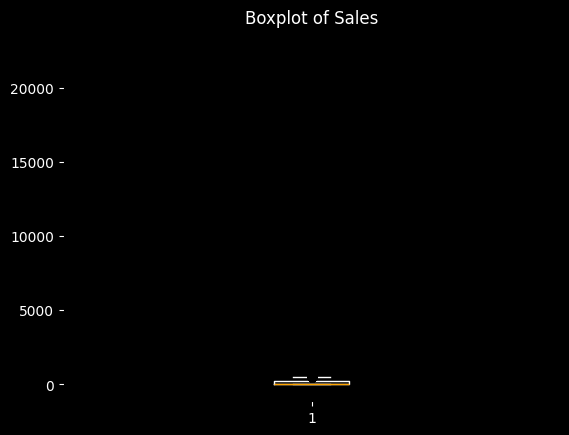

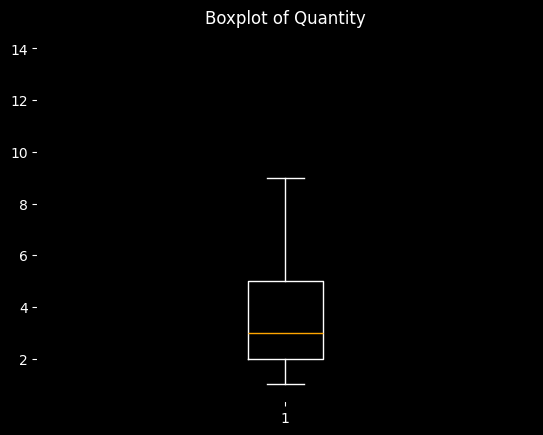

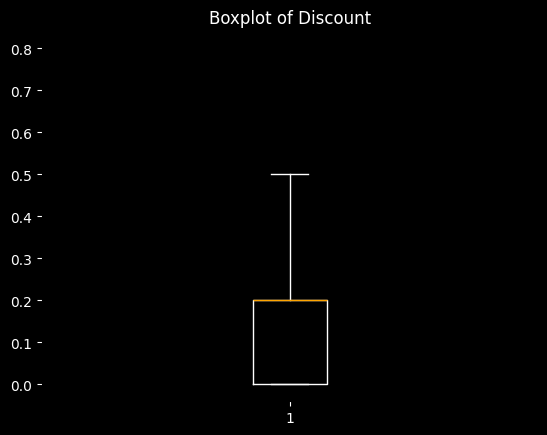

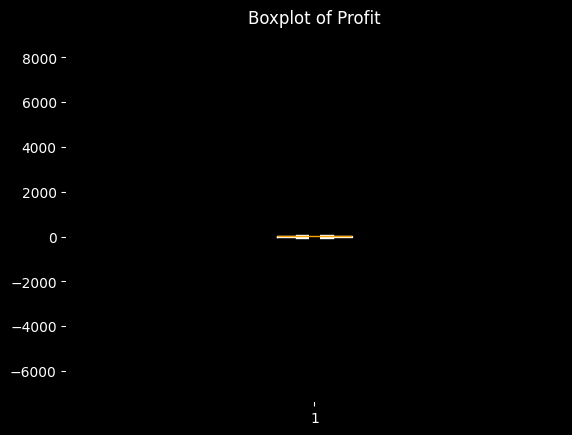

In [137]:
# Membuat boxplot
for n in col_numeric:
    plt.figure()
    plt.boxplot(dfc[n])
    plt.title(f'Boxplot of {n}')
    plt.show()

In [138]:
dfc.describe(include=["object"])

,Order_ID,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub-Category,Product_Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [139]:
obj_col = dfc.select_dtypes(include=["object"]).columns # variable untuk mengambil nama kolom object
obj_value = []

# membuat dictionary untuk tabel unique value
for col in obj_col:
    obj_value.append({
        "column_name" : col, #nama kolom
        "unique_value" : dfc[col].dropna().unique().tolist(), # list unique value 
        "n_unique" : dfc[col].nunique(dropna=True) # jumlah unique value
    })

# membuat data frame dari dictionary unique value
dfc_obj_value = pd.DataFrame(obj_value)

In [140]:
dfc_obj_value

,column_name,unique_value,n_unique
0,Order_ID,"[CA-2016-152156, CA-2016-138688, US-2015-10896...",5009
1,Ship_Mode,"[Second Class, Standard Class, First Class, Sa...",4
2,Customer_ID,"[CG-12520, DV-13045, SO-20335, BH-11710, AA-10...",793
3,Customer_Name,"[Claire Gute, Darrin Van Huff, Sean O'Donnell,...",793
4,Segment,"[Consumer, Corporate, Home Office]",3
5,Country,[United States],1
6,City,"[Henderson, Los Angeles, Fort Lauderdale, Conc...",531
7,State,"[Kentucky, California, Florida, North Carolina...",49
8,Region,"[South, West, Central, East]",4
9,Product_ID,"[FUR-BO-10001798, FUR-CH-10000454, OFF-LA-1000...",1862


# **3. Feature Engineering**

In [141]:
dfc['unit_price'] = round((dfc['Sales'] / (dfc['Quantity'] * (1 - dfc['Discount']))), 2)

In [142]:
df.loc[(df['Quantity'] == 0) | (df['Discount'] == 1), 'unit_price'] = None

In [143]:
dfc['profit_margin'] = round((dfc['Profit'] / dfc['Sales']), 2)

In [144]:
dfc.head(5)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit,unit_price,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,130.98,0.16
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,243.98,0.30
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,7.31,0.47
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,348.21,-0.40
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,13.98,0.11


In [145]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9994 non-null   int64         
 1   Order_ID       9994 non-null   object        
 2   Order_Date     9994 non-null   datetime64[ns]
 3   Ship_Date      9994 non-null   datetime64[ns]
 4   Ship_Mode      9994 non-null   object        
 5   Customer_ID    9994 non-null   object        
 6   Customer_Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal_Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product_ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

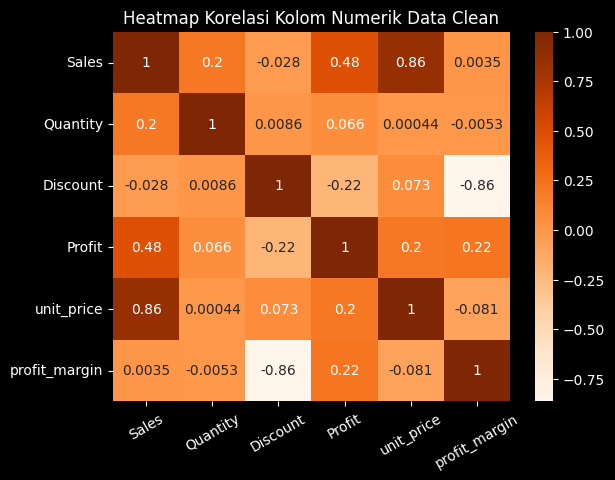

In [146]:
numeric_df = dfc.select_dtypes(include='number')

# (optional) slice kolom kalau mau
numeric_df = numeric_df.iloc[:, 2:]

# buat correlation matrix
corr = numeric_df.corr()

# Heatmap untuk kolom numerik dataframe dfc
sns.heatmap(
    corr, 
    annot=True, 
    annot_kws={'size':10}, 
    cmap='Oranges'
    )

plt.title('Heatmap Korelasi Kolom Numerik Data Clean')
plt.xticks(rotation = 30)
plt.show()

In [147]:
# Uji korelasi/hubungan kolom Discount vs profit_margin
corr, p_value = spearmanr(dfc['Discount'], dfc['profit_margin'])

print(f"Nilai corr/rho: {corr}")
print(f"Nilai P-Value: {p_value}")
print('\n')

if p_value < 0.05:
    print(f"P-Value: {p_value} < 0.05, maka Tolak H0: Terdapat hubungan yang signifikan")

else:
    print(f"P-Value: {p_value} >= 0.05, maka gagal Tolak H0: kemungkinan tidak memiliki hubungan")

Nilai corr/rho: -0.6458262446107126
Nilai P-Value: 0.0


P-Value: 0.0 < 0.05, maka Tolak H0: Terdapat hubungan yang signifikan


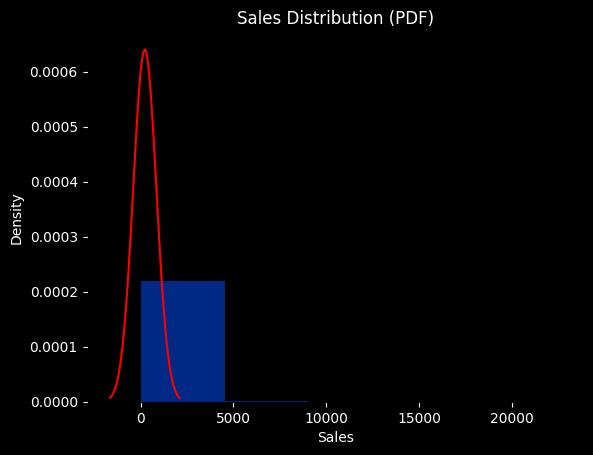

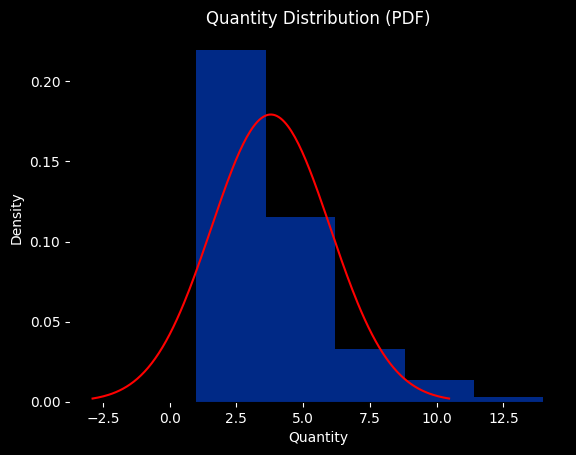

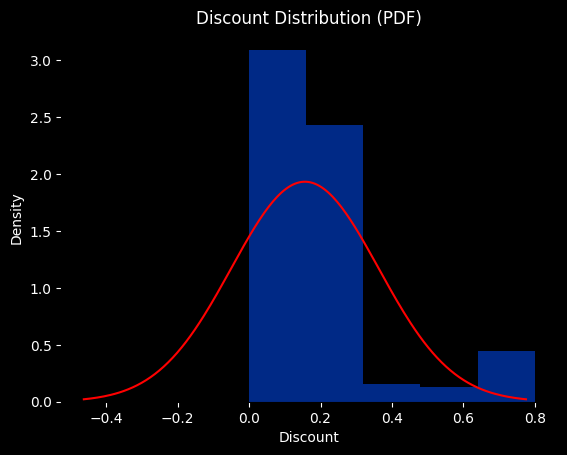

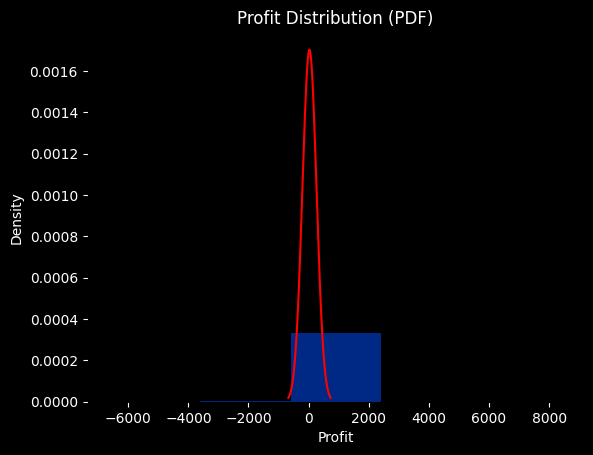

In [148]:
# Membuat garis normalitas
for col in col_numeric:
    mu = dfc[col].mean()
    sigma = np.std(dfc[col])
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 200) 
    pdf = norm.pdf(x, mu, sigma)

    # Membuat histogram distribusi untuk setiap kolom numerik
    plt.hist(
        dfc[col], 
        bins = 5, 
        density=True, 
        alpha=0.6,
        color= "#0045e1"
        )
    plt.plot(
        x, 
        pdf, 
        color='red'
        )
    
    plt.title(f"{col} Distribution (PDF)")
    plt.xlabel(f"{col}")
    plt.ylabel("Density")
    plt.show()

In [149]:
dfc.to_csv('SuperStoreDataset.csv', index=False)